# Project 1 — Celebrity Classification
## Milestone 1: Model Comparison on a 5-Class CelebA Subset

**IE 7615** — Project 1, Milestone 1

**David Fung**

This milestone trains and compares three image-classification architectures on a curated subset of the CelebA dataset (5 identities). The models are: (1) a custom CNN built from scratch, (2) a ResNet50 transfer-learning baseline in feature-extraction mode, and (3) the same ResNet50 backbone with the final convolutional block unfrozen for fine-tuning. All experiments are conducted in a single notebook.

In [1]:
import os
import time
import shutil
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from tensorflow.keras.utils import load_img, img_to_array, to_categorical
from sklearn.model_selection import train_test_split

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.13.1


In [57]:
# PROJECT CONSTANTS
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.keras.utils.set_random_seed(GLOBAL_SEED)

def set_all_seeds():
    np.random.seed(GLOBAL_SEED)
    tf.random.set_seed(GLOBAL_SEED)

BATCH = 16
EPOCHS = 30
VSPLIT = 0.2

IMG_SIZE = (224, 224)
NUM_CLASSES = 5
CLASS_NAMES = ['7', '797', '2619', '4428', '7007']
DATA_DIR = "data/selected_images"

l2_reg = regularizers.l2(1e-3)

# Per-model initial learning rates (reduced during training via ReduceLROnPlateau)
LR_CNN = 1e-4
LR_FE = 1e-3
LR_FT = 1e-4

FT_UNFREEZE_PREFIXES = ('conv5_block3',)

CKPT_DIR = os.path.join(tempfile.gettempdir(), 'celebrity_milestone1_checkpoints')


In [3]:
def plot_history(history, title):
    # Identify overfitting point: where val_acc peaks
    val_acc_series = history.history['val_accuracy']
    peak_epoch = val_acc_series.index(max(val_acc_series)) + 1
    
    epochs_all = range(1, EPOCHS+1)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the chart
    ax.plot(epochs_all, history.history['val_accuracy'], color='steelblue', label='Validation Accuracy')
    ax.plot(epochs_all, history.history['accuracy'], marker='o', color='orange', label='Train Accuracy')
    
    # Annotate the peak
    ax.axvline(peak_epoch, color='red', linestyle=':', alpha=0.6)
    ax.annotate(f'Peak Validation\nEpoch: {peak_epoch}\nVal Acc: {max(val_acc_series):.4f}',
                xy=(peak_epoch, max(val_acc_series)),
                xytext=(peak_epoch + 2, max(val_acc_series) - 0.05),
                arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

    # Plot Info
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f"{title}: {EPOCHS} Epoch Training")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Task 1 — Load, Split, and Prepare Two Input Datasets

This task prepares the 5-class CelebA subset in the following order:

1. Count the images in each class folder.
2. Split each class separately into 70% train / 15% validation / 15% test.
3. Combine the per-class splits into final train / validation / test sets.
4. Create two input datasets:
   - `X_*_cnn`: normalised to `[0, 1]` for the custom CNN.
   - `X_*_resnet`: kept in `[0, 255]` for ResNet50 preprocessing.
5. Display one sample from each dataset type.

Augmentation is applied inside the model during training, not before the data is loaded. For the ResNet50 models, the brightness-augmentation layer uses `value_range=(0, 255)` to match the `[0, 255]` input dataset, and the official `preprocess_input` step is applied immediately before the ResNet50 backbone.


In [4]:
# Step 1 — Check the 5 class folders and count the images in each class
all_files = []
all_labels = []
count_rows = []

for i, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_DIR, class_name)
    class_files = [
        os.path.join(class_dir, fname)
        for fname in sorted(os.listdir(class_dir))
        if fname.endswith('.jpg')
    ]

    all_files.extend(class_files)
    all_labels.extend([i] * len(class_files))
    count_rows.append({'Class': class_name, 'Images': len(class_files)})

count_df = pd.DataFrame(count_rows, columns=['Class', 'Images'])
print(f"Total images: {len(all_files)}")
display(count_df)


Total images: 121


,Class,Images
0,7,24
1,797,25
2,2619,25
3,4428,23
4,7007,24


In [5]:
# Step 2 — Split each class separately into 70% train / 15% validation / 15% test
from collections import defaultdict

files_by_class = defaultdict(list)
for f, lab in zip(all_files, all_labels):
    files_by_class[lab].append(f)

train_files, val_files, test_files = [], [], []
train_labels, val_labels, test_labels = [], [], []
split_rows = []

for cls in sorted(files_by_class.keys()):
    cls_files = files_by_class[cls]

    c_train, c_rest = train_test_split(cls_files, test_size=0.30, random_state=GLOBAL_SEED)
    c_val, c_test = train_test_split(c_rest, test_size=0.5, random_state=GLOBAL_SEED)

    train_files.extend(c_train)
    val_files.extend(c_val)
    test_files.extend(c_test)

    train_labels.extend([cls] * len(c_train))
    val_labels.extend([cls] * len(c_val))
    test_labels.extend([cls] * len(c_test))

    split_rows.append({
        'Class': CLASS_NAMES[cls],
        'Train': len(c_train),
        'Validation': len(c_val),
        'Test': len(c_test)
    })

split_df = pd.DataFrame(split_rows, columns=['Class', 'Train', 'Validation', 'Test'])
display(split_df)


,Class,Train,Validation,Test
0,7,16,4,4
1,797,17,4,4
2,2619,17,4,4
3,4428,16,3,4
4,7007,16,4,4


In [6]:
# Step 3 — Combine the per-class splits into final train / validation / test sets
final_rows = []

for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    row = {'Split': split_name, 'Total': len(labels)}
    for i, name in enumerate(CLASS_NAMES):
        row[name] = labels.count(i)
    final_rows.append(row)

final_df = pd.DataFrame(final_rows)
display(final_df)


,Split,Total,7,797,2619,4428,7007
0,Train,82,16,17,17,16,16
1,Validation,19,4,4,4,3,4
2,Test,20,4,4,4,4,4


In [7]:
# Step 4 — Create two input datasets:
#   X_*_cnn    : normalised to [0, 1] for the custom CNN
#   X_*_resnet : kept in [0, 255] for ResNet50 preprocessing
def load_image_arrays(files, labels):
    x_cnn = np.zeros((len(files), IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)
    x_resnet = np.zeros_like(x_cnn)

    for i, f in enumerate(files):
        img = load_img(f, target_size=IMG_SIZE)
        arr = img_to_array(img).astype(np.float32)

        x_resnet[i] = arr          # [0, 255]
        x_cnn[i] = arr / 255.0     # [0, 1]

    y = to_categorical(labels, NUM_CLASSES)
    return x_cnn, x_resnet, y

X_train_cnn, X_train_resnet, y_train = load_image_arrays(train_files, train_labels)
X_val_cnn, X_val_resnet, y_val = load_image_arrays(val_files, val_labels)
X_test_cnn, X_test_resnet, y_test = load_image_arrays(test_files, test_labels)

print('CNN dataset [0, 1]')
print('  X_train_cnn:', X_train_cnn.shape, 'min=', round(float(X_train_cnn.min()), 4), 'max=', round(float(X_train_cnn.max()), 4))
print('  X_val_cnn:  ', X_val_cnn.shape, 'min=', round(float(X_val_cnn.min()), 4), 'max=', round(float(X_val_cnn.max()), 4))
print('  X_test_cnn: ', X_test_cnn.shape, 'min=', round(float(X_test_cnn.min()), 4), 'max=', round(float(X_test_cnn.max()), 4))

print('ResNet dataset [0, 255]')
print('  X_train_resnet:', X_train_resnet.shape, 'min=', round(float(X_train_resnet.min()), 4), 'max=', round(float(X_train_resnet.max()), 4))
print('  X_val_resnet:  ', X_val_resnet.shape, 'min=', round(float(X_val_resnet.min()), 4), 'max=', round(float(X_val_resnet.max()), 4))
print('  X_test_resnet: ', X_test_resnet.shape, 'min=', round(float(X_test_resnet.min()), 4), 'max=', round(float(X_test_resnet.max()), 4))


CNN dataset [0, 1]
  X_train_cnn: (82, 224, 224, 3) min= 0.0 max= 1.0
  X_val_cnn:   (19, 224, 224, 3) min= 0.0 max= 1.0
  X_test_cnn:  (20, 224, 224, 3) min= 0.0 max= 1.0
ResNet dataset [0, 255]
  X_train_resnet: (82, 224, 224, 3) min= 0.0 max= 255.0
  X_val_resnet:   (19, 224, 224, 3) min= 0.0 max= 255.0
  X_test_resnet:  (20, 224, 224, 3) min= 0.0 max= 255.0


## Task 2 — Custom CNN

Build a compact CNN from scratch: four convolutional blocks (Conv2D → BatchNorm → MaxPool) followed by global average pooling and a dense classifier head. Trained end-to-end with Adam and categorical cross-entropy.

In [77]:
set_all_seeds()

model_cnn = Sequential([
    Input(shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),

    Conv2D(32, 3, activation='relu', kernel_regularizer=l2_reg),
    BatchNormalization(),
    #MaxPooling2D(2),
    Dropout(0.30),

    Conv2D(64, 3, activation='relu', kernel_regularizer=l2_reg),
    BatchNormalization(),
    #MaxPooling2D(2),
    Dropout(0.30),

    Conv2D(128, 3, activation='relu', kernel_regularizer=l2_reg),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.30),
    
    Conv2D(256, 3, activation='relu', kernel_regularizer=l2_reg),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.40),
   
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=l2_reg),
    Dropout(0.50),
    Dense(NUM_CLASSES, activation='softmax')

])

model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR_CNN),
                 loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()
print(f"\nCustom CNN: {model_cnn.count_params():,} parameters")

Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip_24 (RandomFlip  (None, 224, 224, 3)       0         
 )                                                               
                                                                 
 random_rotation_24 (Random  (None, 224, 224, 3)       0         
 Rotation)                                                       
                                                                 
 random_zoom_24 (RandomZoom  (None, 224, 224, 3)       0         
 )                                                               
                                                                 
 random_brightness_24 (Rand  (None, 224, 224, 3)       0         
 omBrightness)                                                   
                                                                 
 random_contrast_24 (Random  (None, 224, 224, 3)     

In [ ]:
print("Training Custom CNN...")
t0 = time.time()

# Store checkpoints in a local temp folder
os.makedirs(CKPT_DIR, exist_ok=True)
cnn_best_ckpt = os.path.join(CKPT_DIR, 'best_cnn.weights.h5')
best_cb_cnn = ModelCheckpoint(
    filepath=cnn_best_ckpt,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

# Add learning-rate scheduling
lr_cb_cnn = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_data=(X_val_cnn, y_val),
    callbacks=[best_cb_cnn, lr_cb_cnn],
    verbose=0
)
cnn_train_time = time.time() - t0

model_cnn.load_weights(cnn_best_ckpt)
test_loss, test_acc_cnn = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Custom CNN - Best Test Accuracy: {test_acc_cnn:.4f}")
print(f"Custom CNN - Training Time: {cnn_train_time:.1f}s")

Training Custom CNN...


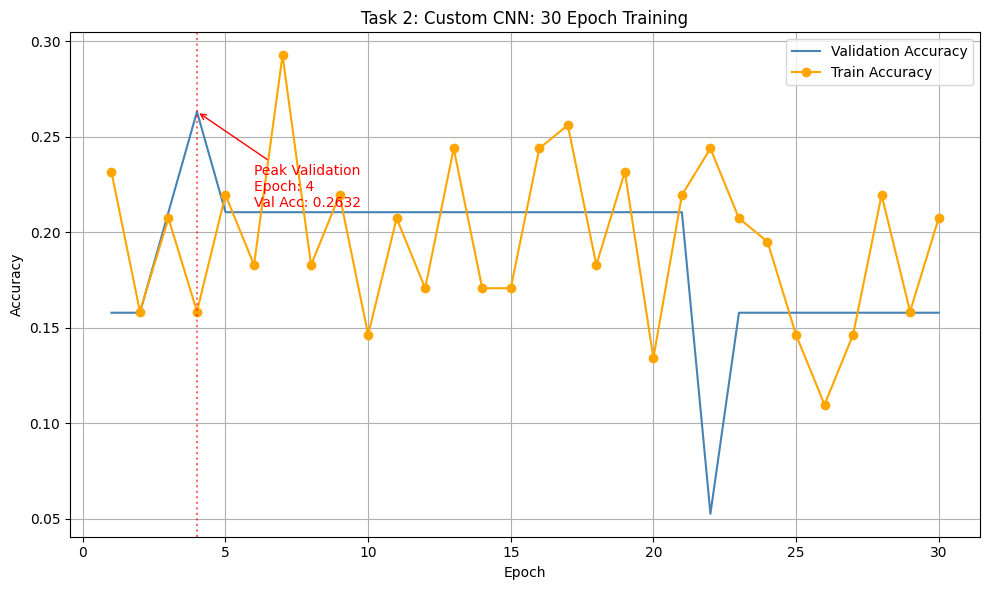

In [76]:
plot_history(history_cnn, "Task 2: Custom CNN")

## Task 3 — ResNet50 Feature Extraction

Load a pretrained ResNet50 (ImageNet weights) with the top layer removed. All backbone weights are frozen; only the newly added classification head (GlobalAveragePooling → Dense → Softmax) is trained.

In [11]:
set_all_seeds()

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model_fe = Sequential([
    Input(shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2, value_range=(0, 255)),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
    # Apply official ResNet50 preprocessing directly to the [0, 255] input
    layers.Lambda(lambda x: preprocess_input(x)),
    base_model,
    GlobalAveragePooling2D(),

    Dense(256, activation='relu', kernel_regularizer=l2_reg),
    Dropout(0.50),
    Dense(NUM_CLASSES, activation='softmax')
])

model_fe.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FE),
                 loss='categorical_crossentropy', metrics=['accuracy'])
trainable_params = sum(w.shape.num_elements() for w in model_fe.trainable_weights)
print(f"\nResNet50 (FE) — Trainable params: {trainable_params:,}")


ResNet50 (FE) — Trainable params: 525,829


In [12]:
print("Training ResNet50 (Feature Extraction)...")
t0 = time.time()

# Store checkpoints in a local temp folder
os.makedirs(CKPT_DIR, exist_ok=True)
fe_best_ckpt = os.path.join(CKPT_DIR, 'best_fe.weights.h5')
best_cb_fe = ModelCheckpoint(
    filepath=fe_best_ckpt,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

# Add learning-rate scheduling
lr_cb_fe = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

history_fe = model_fe.fit(
    X_train_resnet, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_data=(X_val_resnet, y_val),
    callbacks=[best_cb_fe, lr_cb_fe],
    verbose=0
)
fe_train_time = time.time() - t0

model_fe.load_weights(fe_best_ckpt)
test_loss, test_acc_fe = model_fe.evaluate(X_test_resnet, y_test, verbose=0)

print(f"ResNet50 (FE) - Best Test Accuracy: {test_acc_fe:.4f}")
print(f"ResNet50 (FE) - Training Time: {fe_train_time:.1f}s")

Training ResNet50 (Feature Extraction)...
ResNet50 (FE) - Best Test Accuracy: 0.7500
ResNet50 (FE) - Training Time: 65.1s


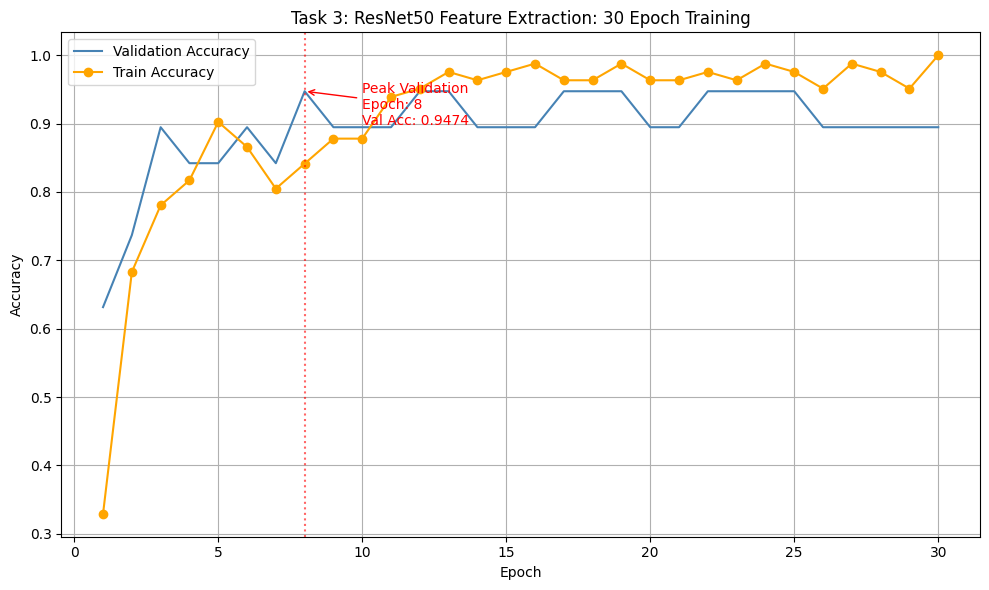

In [13]:
plot_history(history_fe, "Task 3: ResNet50 Feature Extraction")

## Task 4 — ResNet50 Fine-Tuning

Same ResNet50 backbone as Task 3, but the final convolutional block (`conv5_block3`) is unfrozen for fine-tuning. The model is initialized from the best feature-extraction weights when available, then trained with a smaller learning rate (`1e-4`) and lighter dropout so the pretrained features are adapted gently rather than disrupted.

In [ ]:
set_all_seeds()

base_model_ft = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model_ft.layers:
    if not any(layer.name.startswith(prefix) for prefix in FT_UNFREEZE_PREFIXES):
        layer.trainable = False

model_ft = Sequential([
    Input(shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2, value_range=(0, 255)),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
    # Apply official ResNet50 preprocessing directly to the [0, 255] input
    layers.Lambda(lambda x: preprocess_input(x)),
    base_model_ft,
    GlobalAveragePooling2D(),
    
    Dense(256, activation='relu', kernel_regularizer=l2_reg),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation='softmax')
])

# Use LR_FT constant for consistency
model_ft.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FT),
                 loss='categorical_crossentropy', metrics=['accuracy'])

# Two-stage fine-tuning: start from the best feature-extraction weights when they are available
fe_best_ckpt_for_init = os.path.join(CKPT_DIR, 'best_fe.weights.h5')
if os.path.exists(fe_best_ckpt_for_init):
    model_ft.load_weights(fe_best_ckpt_for_init)
    print(f"Initialized ResNet50 (FT) from FE best weights: {fe_best_ckpt_for_init}")
else:
    print("FE checkpoint not found; initializing ResNet50 (FT) from ImageNet weights")

trainable_params = sum(w.shape.num_elements() for w in model_ft.trainable_weights)
print(f"\nResNet50 (FT) — Trainable params: {trainable_params:,}")

Initialized ResNet50 (FT) from FE best weights: C:\Users\david\AppData\Local\Temp\celebrity_milestone1_checkpoints\best_fe.weights.h5

ResNet50 (FT) — Trainable params: 4,991,493


In [15]:
print("Training ResNet50 (Fine-Tuning)...")
t0 = time.time()

# Store checkpoints in a local temp folder
os.makedirs(CKPT_DIR, exist_ok=True)
ft_best_ckpt = os.path.join(CKPT_DIR, 'best_ft.weights.h5')
best_cb_ft = ModelCheckpoint(
    filepath=ft_best_ckpt,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

# Add learning-rate scheduling
lr_cb_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

history_ft = model_ft.fit(
    X_train_resnet, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_data=(X_val_resnet, y_val),
    callbacks=[best_cb_ft, lr_cb_ft],
    verbose=0
)
ft_train_time = time.time() - t0

model_ft.load_weights(ft_best_ckpt)
test_loss, test_acc_ft = model_ft.evaluate(X_test_resnet, y_test, verbose=0)

print(f"ResNet50 (FT) - Best Test Accuracy: {test_acc_ft:.4f}")
print(f"ResNet50 (FT) - Training Time: {ft_train_time:.1f}s")

Training ResNet50 (Fine-Tuning)...
ResNet50 (FT) - Best Test Accuracy: 0.8500
ResNet50 (FT) - Training Time: 72.3s


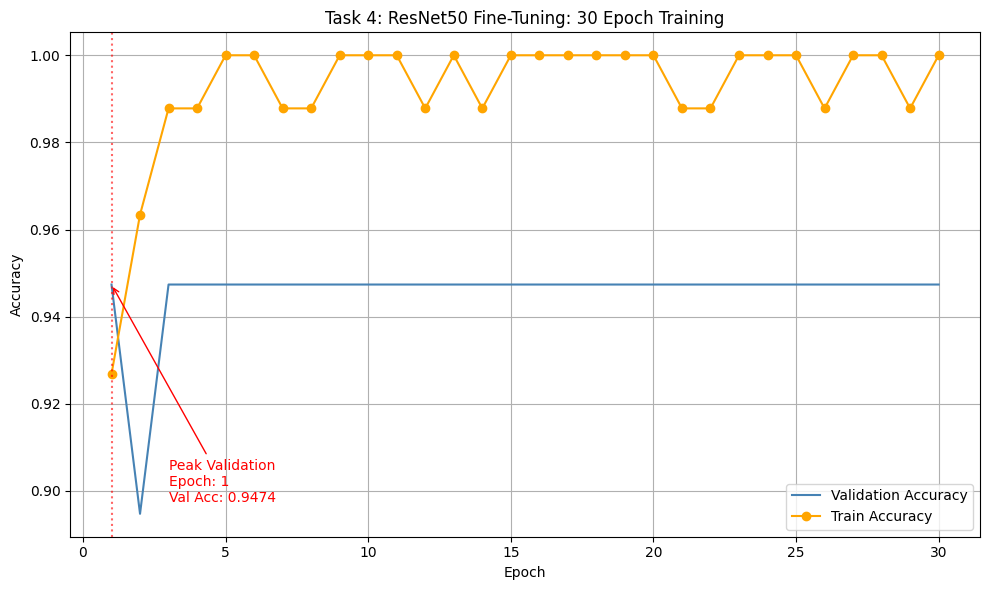

In [16]:
plot_history(history_ft, "Task 4: ResNet50 Fine-Tuning")

## Task 5 — Full Comparison

Produce a summary table comparing all three architectures on test accuracy and trainable parameter count. Display a side-by-side validation accuracy comparison.

In [17]:
summary_data = {
    'Architecture': ['Custom CNN', 'ResNet50 (Feature Extraction)', 'ResNet50 (Fine-Tuning)'],
    'Test Accuracy': [test_acc_cnn, test_acc_fe, test_acc_ft],
    'Training Time (s)': [round(cnn_train_time, 1), round(fe_train_time, 1), round(ft_train_time, 1)],
    'Trainable Parameters': [
        model_cnn.count_params(),
        sum(w.shape.num_elements() for w in model_fe.trainable_weights),
        sum(w.shape.num_elements() for w in model_ft.trainable_weights)
    ]
}
df = pd.DataFrame(summary_data)
print("\n--- Final Comparison Table ---")
display(df)


--- Final Comparison Table ---


,Architecture,Test Accuracy,Training Time (s),Trainable Parameters
0,Custom CNN,0.15,43.6,28069
1,ResNet50 (Feature Extraction),0.75,65.1,525829
2,ResNet50 (Fine-Tuning),0.85,72.3,4991493


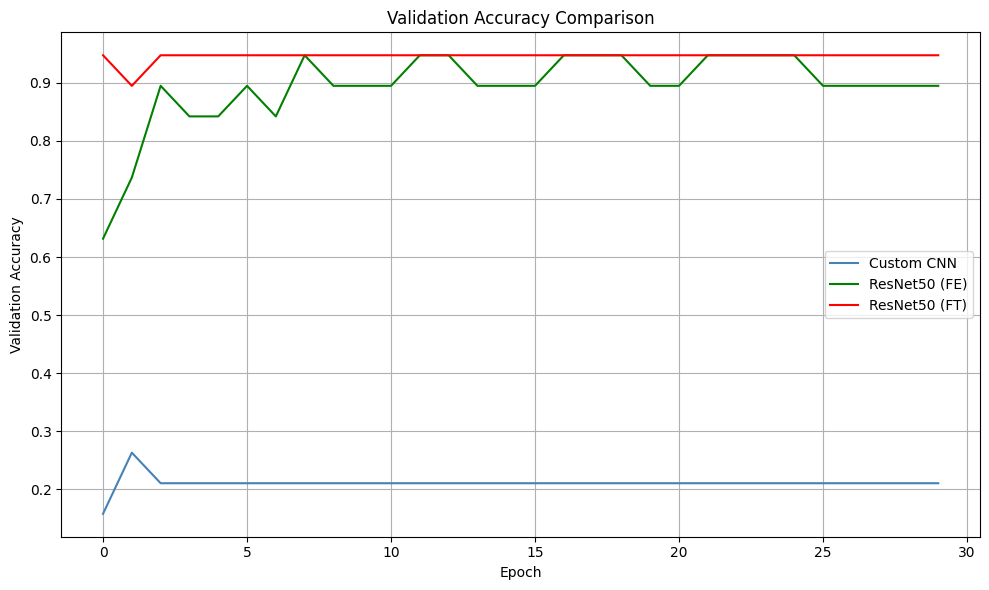

In [18]:
# Side-by-side validation accuracy comparison
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(history_cnn.history['val_accuracy'], color='steelblue', label='Custom CNN')
ax.plot(history_fe.history['val_accuracy'], color='green', label='ResNet50 (FE)')
ax.plot(history_ft.history['val_accuracy'], color='red', label='ResNet50 (FT)')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Validation Accuracy Comparison')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Cleanup

Delete the temporary checkpoint folder used by this notebook after the best weights have been loaded and the final comparison has been displayed.


In [19]:
# [CHANGED] Delete the local temp checkpoint folder used for this notebook
#shutil.rmtree('checkpoints', ignore_errors=True)
shutil.rmtree(CKPT_DIR, ignore_errors=True)
print("Deleted the temporary checkpoint folder (if it exists).")


Deleted the temporary checkpoint folder (if it exists).


## Conclusion

[Write-up: Compare the three architectures. Discuss how transfer learning (feature extraction vs fine-tuning) impacts accuracy and training speed on this small 5-class dataset. Note that with only ~25 images per class, pretrained features provide a significant advantage over training a CNN from scratch. The fine-tuning variant adapts those features to the specific identities, typically yielding the best accuracy at the cost of slightly more training compute.]